# hibari 기초분석

### 1. mid 파일 전처리
* 데이터가 어떤 형태로 들어있는지 봅니다.

In [2]:
import pretty_midi

file_name = "Ryuichi_Sakamoto_-_hibari.mid"
midi_data = pretty_midi.PrettyMIDI(file_name)
for instrument in midi_data.instruments:
    for note in instrument.notes:
        print(note)

c:\Users\82104\Developments\.venv\lib\site-packages\pretty_midi\pretty_midi.py:100: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


Note(start=0.000000, end=0.429924, pitch=67, velocity=38)
Note(start=0.000000, end=0.861743, pitch=52, velocity=38)
Note(start=0.000000, end=0.861743, pitch=59, velocity=38)
Note(start=0.000000, end=0.861743, pitch=62, velocity=38)
Note(start=0.454545, end=0.884470, pitch=72, velocity=38)
Note(start=0.909091, end=1.339015, pitch=69, velocity=38)
Note(start=0.909091, end=1.339015, pitch=74, velocity=38)
Note(start=0.909091, end=1.770834, pitch=53, velocity=38)
Note(start=0.909091, end=1.770834, pitch=60, velocity=38)
Note(start=1.363636, end=1.793561, pitch=81, velocity=38)
Note(start=1.818182, end=2.248106, pitch=71, velocity=38)
Note(start=1.818182, end=2.248106, pitch=79, velocity=38)
Note(start=1.818182, end=2.679925, pitch=55, velocity=38)
Note(start=1.818182, end=2.679925, pitch=64, velocity=38)
Note(start=2.272727, end=2.702652, pitch=76, velocity=38)
Note(start=2.727273, end=3.157197, pitch=67, velocity=38)
Note(start=2.727273, end=3.157197, pitch=72, velocity=38)
Note(start=2.7

* 기본적으로 아래와 같은 형식으로 처리합니다.
* 즉, (start, pitch, end) tuple을 list에 담습니다.

In [3]:
midi_data = pretty_midi.PrettyMIDI(file_name)

notes = []
for instrument in midi_data.instruments:
    for note in instrument.notes:
        notes.append((note.start, note.pitch, note.end))

notes

[(0.0, 67, 0.42992428541666666),
 (0.0, 52, 0.8617425104166667),
 (0.0, 59, 0.8617425104166667),
 (0.0, 62, 0.8617425104166667),
 (0.4545455, 72, 0.8844697854166667),
 (0.909091, 69, 1.3390152854166666),
 (0.909091, 74, 1.3390152854166666),
 (0.909091, 53, 1.7708335104166666),
 (0.909091, 60, 1.7708335104166666),
 (1.3636365, 81, 1.7935607854166666),
 (1.818182, 71, 2.2481062854166667),
 (1.818182, 79, 2.2481062854166667),
 (1.818182, 55, 2.6799245104166665),
 (1.818182, 64, 2.6799245104166665),
 (2.2727275, 76, 2.7026517854166667),
 (2.727273, 67, 3.1571972854166668),
 (2.727273, 72, 3.1571972854166668),
 (2.727273, 57, 3.5890155104166666),
 (2.727273, 64, 3.5890155104166666),
 (3.1818185, 74, 3.611742785416667),
 (3.636364, 69, 4.066288285416666),
 (3.636364, 76, 4.066288285416666),
 (3.636364, 59, 4.498106510416667),
 (3.636364, 65, 4.498106510416667),
 (4.0909095, 72, 4.5208337854166665),
 (4.545455, 74, 4.9753792854166665),
 (4.545455, 60, 7.134470410416666),
 (4.545455, 65, 7.134

* 다만 hibari의 최소 시간단위를 고려하여 8분음표를 기준으로 정제합니다.

In [4]:
from util import adjust_to_eighth_note

adjusted_notes = adjust_to_eighth_note(file_name)

1th instrument ending : index 2006
2th instrument ending : index 3953


In [5]:
adjusted_notes

[(0, 67, 1),
 (0, 52, 2),
 (0, 59, 2),
 (0, 62, 2),
 (1, 72, 2),
 (2, 69, 3),
 (2, 74, 3),
 (2, 53, 4),
 (2, 60, 4),
 (3, 81, 4),
 (4, 71, 5),
 (4, 79, 5),
 (4, 55, 6),
 (4, 64, 6),
 (5, 76, 6),
 (6, 67, 7),
 (6, 72, 7),
 (6, 57, 8),
 (6, 64, 8),
 (7, 74, 8),
 (8, 69, 9),
 (8, 76, 9),
 (8, 59, 10),
 (8, 65, 10),
 (9, 72, 10),
 (10, 74, 11),
 (10, 60, 16),
 (10, 65, 16),
 (11, 69, 16),
 (16, 67, 17),
 (16, 52, 18),
 (16, 59, 18),
 (16, 62, 18),
 (17, 72, 18),
 (18, 69, 19),
 (18, 74, 19),
 (18, 53, 20),
 (18, 60, 20),
 (19, 81, 20),
 (20, 71, 21),
 (20, 79, 21),
 (20, 55, 22),
 (20, 64, 22),
 (21, 76, 22),
 (22, 67, 23),
 (22, 72, 23),
 (22, 57, 24),
 (22, 64, 24),
 (23, 76, 24),
 (24, 69, 25),
 (24, 74, 25),
 (24, 59, 26),
 (24, 65, 26),
 (25, 71, 26),
 (26, 67, 27),
 (26, 72, 27),
 (26, 57, 32),
 (26, 64, 32),
 (27, 65, 32),
 (32, 67, 33),
 (32, 52, 34),
 (32, 59, 34),
 (32, 62, 34),
 (33, 72, 34),
 (34, 69, 35),
 (34, 74, 35),
 (34, 53, 36),
 (34, 60, 36),
 (35, 81, 36),
 (36, 71, 37

In [6]:
print(adjusted_notes[2005])
print(adjusted_notes[2006])
print(len(adjusted_notes))

(1083, 65, 1088)
(0, 67, 1)
3953


* instrument 단위로 자릅니다

In [7]:
# instrument 단위로 자른 list
adn_1 = adjusted_notes[:2006]
adn_2 = adjusted_notes[2006:]

* pitch의 진행을 확인해보면 똑같이 진행됨을 알 수 있습니다.

In [8]:
# module of melody keeps being repeated
limit = min(len(adn_1), len(adn_2))

pitch_1 = []
for start, pitch, end in adn_1[:limit] :
    pitch_1.append(pitch)

pitch_2 = []
for start, pitch, end in adn_2[:limit] :
    pitch_2.append(pitch)

if not pitch_1 == pitch_2 :
    print("inconsistent notes proceeding detected")

* 해당 pitch가 타건되는 시점, 즉 onset은 어느 시점부터 차이가 있습니다.

In [9]:
for i in range(0, limit) :
    limit = i

    start_1 = []
    for start, pitch, end in adn_1[:limit] :
        start_1.append(start)

    start_2 = []
    for start, pitch, end in adn_2[:limit] :
        start_2.append(start)

    if not start_1 == start_2 :
        print(f"inconsistent onsets detected at index {i}")
        break


inconsistent onsets detected at index 60


In [10]:
adn_1[60], adn_2[60]

((32, 52, 34), (33, 52, 35))

* 실제 악보를 참고했을 때 instrument 2에 해당하는 adn_2는 33번째 박자 (5th 마디 2박자) 처음에 들어가야 함을 확인할 수 있습니다

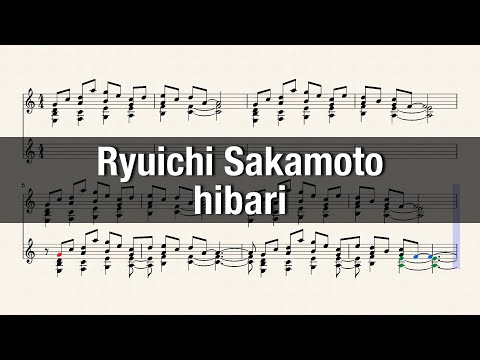

In [11]:
from IPython.display import YouTubeVideo
YouTubeVideo("6TmI6vvaDfw", width=600, height=400)

* 비슷한 침습 현상이 132마디에서 연주가 끝나는 adn_1(inst 1)에서도 관찰됩니다.
  (133~136마디에는 inst 2만 연주합니다.)

In [12]:
adn_1[-59:]

[(1056, 67, 1057),
 (1056, 52, 1058),
 (1056, 59, 1058),
 (1056, 62, 1058),
 (1057, 72, 1058),
 (1058, 69, 1059),
 (1058, 74, 1059),
 (1058, 53, 1060),
 (1058, 60, 1060),
 (1059, 81, 1060),
 (1060, 71, 1061),
 (1060, 79, 1061),
 (1060, 55, 1062),
 (1060, 64, 1062),
 (1061, 76, 1062),
 (1062, 67, 1063),
 (1062, 72, 1063),
 (1062, 57, 1064),
 (1062, 64, 1064),
 (1063, 74, 1064),
 (1064, 69, 1065),
 (1064, 76, 1065),
 (1064, 59, 1066),
 (1064, 65, 1066),
 (1065, 72, 1066),
 (1066, 74, 1067),
 (1066, 60, 1072),
 (1066, 65, 1072),
 (1067, 69, 1072),
 (1072, 67, 1073),
 (1072, 52, 1074),
 (1072, 59, 1074),
 (1072, 62, 1074),
 (1073, 72, 1074),
 (1074, 69, 1075),
 (1074, 74, 1075),
 (1074, 53, 1076),
 (1074, 60, 1076),
 (1075, 81, 1076),
 (1076, 71, 1077),
 (1076, 79, 1077),
 (1076, 55, 1078),
 (1076, 64, 1078),
 (1077, 76, 1078),
 (1078, 67, 1079),
 (1078, 72, 1079),
 (1078, 57, 1080),
 (1078, 64, 1080),
 (1079, 76, 1080),
 (1080, 69, 1081),
 (1080, 74, 1081),
 (1080, 59, 1082),
 (1080, 65, 

In [13]:
1056 / 8

132.0

* 따라서 아래와 같이 정제해줍니다.

In [14]:
adn_1_real = adn_1[:-59]
adn_2_real = adn_2[59:]

adjusted_notes_real = adn_1_real + adn_2_real

### 2. 모듈 구조 분석
* 아까 inst 1과 inst 2에서 pitch의 진행이 일치함을 봤습니다. 해당 진행 안에서도 일정한 모듈(튜플 59개, 32박자-4마디)이 반복됨을 보입니다.
* 결과를 먼저 밝히고 시작하자면, 아래와 같습니다 :

In [15]:
from util import notes_freq_gcd_checker

num_repeat_1 = len(adn_1_real) / 59
num_repeat_2 = len(adn_2_real) / 59

print(f'the number of time for each part to iterate module is repectively, {num_repeat_1, num_repeat_2}')
print("\n")

notes_freq_gcd_checker(adjusted_notes_real)

the number of time for each part to iterate module is repectively, (33.0, 32.0)


65 is a greatest common divisor for 
counts for which each notes appearing in hibari


#### 2-1. 모듈 Onset
* inst 1은 주기적으로 전개되는 것을 확인할 수 있다.

In [16]:
for i in range(0, len(adn_1_real), 59) :
    print(adn_1_real[i], adn_1_real[i][0]/32)

(0, 67, 1) 0.0
(32, 67, 33) 1.0
(64, 67, 65) 2.0
(96, 67, 97) 3.0
(128, 67, 129) 4.0
(160, 67, 161) 5.0
(192, 67, 193) 6.0
(224, 67, 225) 7.0
(256, 67, 257) 8.0
(288, 67, 289) 9.0
(320, 67, 321) 10.0
(352, 67, 353) 11.0
(384, 67, 385) 12.0
(416, 67, 417) 13.0
(448, 67, 449) 14.0
(480, 67, 481) 15.0
(512, 67, 513) 16.0
(544, 67, 545) 17.0
(576, 67, 577) 18.0
(608, 67, 609) 19.0
(640, 67, 641) 20.0
(672, 67, 673) 21.0
(704, 67, 705) 22.0
(736, 67, 737) 23.0
(768, 67, 769) 24.0
(800, 67, 801) 25.0
(832, 67, 833) 26.0
(864, 67, 865) 27.0
(896, 67, 897) 28.0
(928, 67, 929) 29.0
(960, 67, 961) 30.0
(992, 67, 993) 31.0
(1024, 67, 1025) 32.0


* inst 2는 그렇지 않다.

In [17]:
j = 0
misfitness = []
for i in range(0, len(adn_2_real), 59) :
    misfit_i = adn_2_real[i][0]/32 - (j+1)
    misfitness.append(misfit_i)
    print(adn_2_real[i], misfit_i)
    j += 1


(33, 67, 34) 0.03125
(66, 67, 67) 0.0625
(99, 67, 100) 0.09375
(132, 67, 133) 0.125
(165, 67, 166) 0.15625
(198, 67, 199) 0.1875
(231, 67, 232) 0.21875
(264, 67, 265) 0.25
(297, 67, 298) 0.28125
(330, 67, 331) 0.3125
(363, 67, 364) 0.34375
(396, 67, 397) 0.375
(429, 67, 430) 0.40625
(462, 67, 463) 0.4375
(495, 67, 496) 0.46875
(528, 67, 529) 0.5
(561, 67, 562) 0.53125
(594, 67, 595) 0.5625
(627, 67, 628) 0.59375
(660, 67, 661) 0.625
(693, 67, 694) 0.65625
(726, 67, 727) 0.6875
(759, 67, 760) 0.71875
(792, 67, 793) 0.75
(825, 67, 826) 0.78125
(858, 67, 859) 0.8125
(891, 67, 892) 0.84375
(924, 67, 925) 0.875
(957, 67, 958) 0.90625
(990, 67, 991) 0.9375
(1023, 67, 1024) 0.96875
(1056, 67, 1057) 1.0


* 정확히 일정한 간격으로 4마디 단위로 봤을 때 조금씩 밀려난다.

In [18]:
misfit_diff = set()
for i in range(len(misfitness)-1) :
    diff = misfitness[i+1] - misfitness[i]
    misfit_diff.add(diff)

misfit_diff # 0.03125 = 1 / 32 = 1 / (8*4)

{0.03125}

* 요약 : inst 1은 정확히 4마디마다 반복되는 반면 inst 2는 1박자씩 쉬고(8분쉼표), 반복됨을 알 수 있다.

#### 2-2. 모듈 구조 확인
* 모듈이 변주되거나 그 밖의 다른 멜로디는 등장하지 않습니다.

In [19]:
from util import group_pitches

period = 59
list_to_see = adn_1_real
len_list = len(list_to_see)
iteration = len_list//period # 33 = 1947 / 59

modules_analyzed = []
for i in range(0, iteration) :
    module_pitch = list_to_see[period*i : period*(i+1)] 
    module_note = [(x, y, z) for x, y, z in module_pitch]

    # 그룹화된 데이터 얻기 : (start, end) 단위로 묶는다.
    module_gp = group_pitches(module_note, pithces_only=True)
    modules_analyzed.append(module_gp)

modules_analyzed

[[{67},
  {52, 59, 62},
  {72},
  {69, 74},
  {53, 60},
  {81},
  {71, 79},
  {55, 64},
  {76},
  {67, 72},
  {57, 64},
  {74},
  {69, 76},
  {59, 65},
  {72},
  {74},
  {60, 65},
  {69},
  {67},
  {52, 59, 62},
  {72},
  {69, 74},
  {53, 60},
  {81},
  {71, 79},
  {55, 64},
  {76},
  {67, 72},
  {57, 64},
  {76},
  {69, 74},
  {59, 65},
  {71},
  {67, 72},
  {57, 64},
  {65}],
 [{67},
  {52, 59, 62},
  {72},
  {69, 74},
  {53, 60},
  {81},
  {71, 79},
  {55, 64},
  {76},
  {67, 72},
  {57, 64},
  {74},
  {69, 76},
  {59, 65},
  {72},
  {74},
  {60, 65},
  {69},
  {67},
  {52, 59, 62},
  {72},
  {69, 74},
  {53, 60},
  {81},
  {71, 79},
  {55, 64},
  {76},
  {67, 72},
  {57, 64},
  {76},
  {69, 74},
  {59, 65},
  {71},
  {67, 72},
  {57, 64},
  {65}],
 [{67},
  {52, 59, 62},
  {72},
  {69, 74},
  {53, 60},
  {81},
  {71, 79},
  {55, 64},
  {76},
  {67, 72},
  {57, 64},
  {74},
  {69, 76},
  {59, 65},
  {72},
  {74},
  {60, 65},
  {69},
  {67},
  {52, 59, 62},
  {72},
  {69, 74},
  {53,

In [21]:
parts_to_check = []
for i in range(iteration-1):  
    for j in range(35) : # len(modules_analyzed[i]) for any i
        if not modules_analyzed[i][j] == modules_analyzed[i+1][j] :
            parts_to_check.append((i, j))

parts_to_check

[]

* parts_to_check이 비어있는 것을 보니 불일치는 없습니다.
* list_to_see를 adn_2_real로 바꿔봐도 59개 단위로 끊은 튜플 list인 module_gp이 인덱스가 연속하는 것끼리 일치함을 볼 수 있습니다.

#### 2-3. 모듈 추출
* onset이 아닌 음의 길이에 의해 특정 시점에서 동시에 활성화된 것을 기준으로 구한 화음 조합

In [22]:
from util import notes_analyzer
from collections import defaultdict

notes, pitch_to_note, __ = notes_analyzer(adjusted_notes_real)

module_pitch = adn_1_real[:period]
module_note = [(x, pitch_to_note.get(y, y), z) for x, y, z in module_pitch]

module_dict = defaultdict(set)
for start, pitch, end in module_note:
    for i in range(start, end):
        module_dict[i].add(pitch)

# result 딕셔너리의 values를 순회하며 고유한 set(chord composition)을 찾음
module_set = set()
for value_set in module_dict.values():
    module_set.add(frozenset(value_set))

# 결과 출력 (frozenset은 set으로 다시 변환하여 출력)
for unique_set in module_set:
    print(set(unique_set))

{'E4', 'G5', 'G3', 'B4'}
{'C5', 'F4', 'B3'}
{'E4', 'E5', 'G3'}
{'C5', 'E3', 'D4', 'B3'}
{'C4', 'A5', 'F3'}
{'C4', 'F3', 'A4', 'D5'}
{'E4', 'A3', 'D5'}
{'F4', 'B3', 'B4'}
{'C4', 'A4', 'F4'}
{'F4', 'E5', 'A4', 'B3'}
{'E4', 'A3', 'F4'}
{'F4', 'A4', 'B3', 'D5'}
{'C5', 'A3', 'G4', 'E4'}
{'C4', 'F4', 'D5'}
{'E4', 'A3', 'E5'}
{'G4', 'E3', 'D4', 'B3'}


* 사용된 음의 Pitch 이름과 빈도수, 주파수 (TakensEmbeding 시도 과정 중 덧붙인)
* 총 17개 : E3 ~ B3 5개 / 4옥타브 흰 건반 7개 / C5 ~ G5 중 F5 제외 4개

In [90]:
notes

,Pitch,count,Note Name,Frequency
0,72,390,C5,523.251131
1,64,325,E4,329.627557
2,74,325,D5,587.329536
3,67,325,G4,391.995436
4,69,325,A4,440.000000
5,65,260,F4,349.228231
6,59,260,B3,246.941651
7,76,260,E5,659.255114
8,57,195,A3,220.000000
9,60,195,C4,261.625565


### 3. 기존 가중치 계산 방식의 한계 (hibari 특성상)
* 가설 : module 자체에 내제된 빈도수만큼으로 환원될 것이다.
* bipartiton(inst 1과 2사이에만) 가중치를 줍니다.

In [23]:
from util import label_active_chord_by_onset

adn_1_chord = label_active_chord_by_onset(adn_1_real)
adn_2_chord = label_active_chord_by_onset(adn_2_real)

In [24]:
print(len(adn_1_real) / 59, len(adn_2_real) / 59)

33.0 32.0


* adn_2_real의 경우 32개의 모듈 사이에 31개의 8분쉼표가 있는데

In [127]:
empty_indices = [i for i, x in enumerate(adn_2_chord) if x is None]
for idx in empty_indices :
    print(idx%32)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30


* 첫번째 모듈 앞에도 8분쉼표를 하나 더해놓고 33으로 나눠야 정수로 떨어진다.

In [128]:
print(len(adn_1_chord) / 32, (len(adn_2_chord) + 1) / (32 + 1))

33.0 32.0


In [129]:
adn_2_chord

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 11,
 11,
 11,
 11,
 0,
 1,
 2,
 3,
 4,
 5,
 6,
 12,
 13,
 14,
 15,
 16,
 16,
 16,
 16,
 16,
 None,
 0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 11,
 11,
 11,
 11,
 0,
 1,
 2,
 3,
 4,
 5,
 6,
 12,
 13,
 14,
 15,
 16,
 16,
 16,
 16,
 16,
 None,
 0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 11,
 11,
 11,
 11,
 0,
 1,
 2,
 3,
 4,
 5,
 6,
 12,
 13,
 14,
 15,
 16,
 16,
 16,
 16,
 16,
 None,
 0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 11,
 11,
 11,
 11,
 0,
 1,
 2,
 3,
 4,
 5,
 6,
 12,
 13,
 14,
 15,
 16,
 16,
 16,
 16,
 16,
 None,
 0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 11,
 11,
 11,
 11,
 0,
 1,
 2,
 3,
 4,
 5,
 6,
 12,
 13,
 14,
 15,
 16,
 16,
 16,
 16,
 16,
 None,
 0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 11,
 11,
 11,
 11,
 0,
 1,
 2,
 3,
 4,
 5,
 6,
 12,
 13,
 14,
 15,
 16,
 16,
 16,
 16,
 16,
 None,
 0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 11,
 11,
 11,
 11,
 0,
 1,
 2,
 3,
 4,
 5,
 6,
 1

* 두 list에서 인덱스를 일치시켜 비교할 수 있는 범위(5마디 2박자 ~ 132마디)만 자릅니다.

In [ ]:
# (length of adn_i_chord) = (# module repeated) * (length of each period)
# adn_1_chord : 1056 = 33 * 32
# adn_2_chord : (1 + 1055) = 32 * 33 
# 임을 고려할 때

# len = 1023
adn_1_chord_ = adn_1_chord[33:] 
adn_2_chord_ = adn_2_chord[:-32]

* 가중치 계산 결과를 확인해보면 대칭에 '가까운' 결과가 나옵니다.

In [149]:
from util import compare_lists
import pandas as pd

lag = 1
weight_mtrx = compare_lists(adn_1_chord_, adn_2_chord_, lag)
weight_mtrx = pd.DataFrame(weight_mtrx)
weight_mtrx


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,7,6,8,8,8,8,8,4,4,4,4,19,4,4,4,4,18
1,6,8,6,8,8,8,8,4,4,4,4,20,4,4,4,4,18
2,8,6,8,6,8,8,8,4,4,4,4,20,4,4,4,4,18
3,8,8,6,8,6,8,8,4,4,4,4,20,4,4,4,4,18
4,8,8,8,6,8,6,8,4,4,4,4,20,4,4,4,4,18
5,8,8,8,8,6,8,6,4,4,4,4,20,4,4,4,4,18
6,8,8,8,8,8,6,8,3,4,4,4,20,3,4,4,4,18
7,4,4,4,4,4,4,3,2,1,2,2,10,2,2,2,2,9
8,4,4,4,4,4,4,4,1,2,1,2,10,2,2,2,2,9
9,4,4,4,4,4,4,4,2,1,2,1,10,2,2,2,2,9


* 모듈 1개에서 각 화음의 등장빈도(혹은 지속길이)를 확인하면 위의 결과와 합치함을 알 수 있습니다.

In [146]:
module_chord_label = pd.DataFrame(adn_1_chord[:32])
module_chord_label.value_counts().to_frame()

,count
0,
16,5
11,5
5,2
1,2
6,2
0,2
4,2
3,2
2,2
